Plot Spectrogram จาก CSV

In [24]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_spectrograms(folder, max_cols=10):
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    n = len(files)

    cols = max_cols
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 2, rows * 2))

    for i, f in enumerate(files):
        data = pd.read_csv(f, header=None).values

        plt.subplot(rows, cols, i + 1)
        plt.imshow(data, aspect='auto', origin='lower')
        plt.title(os.path.basename(f), fontsize=6)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

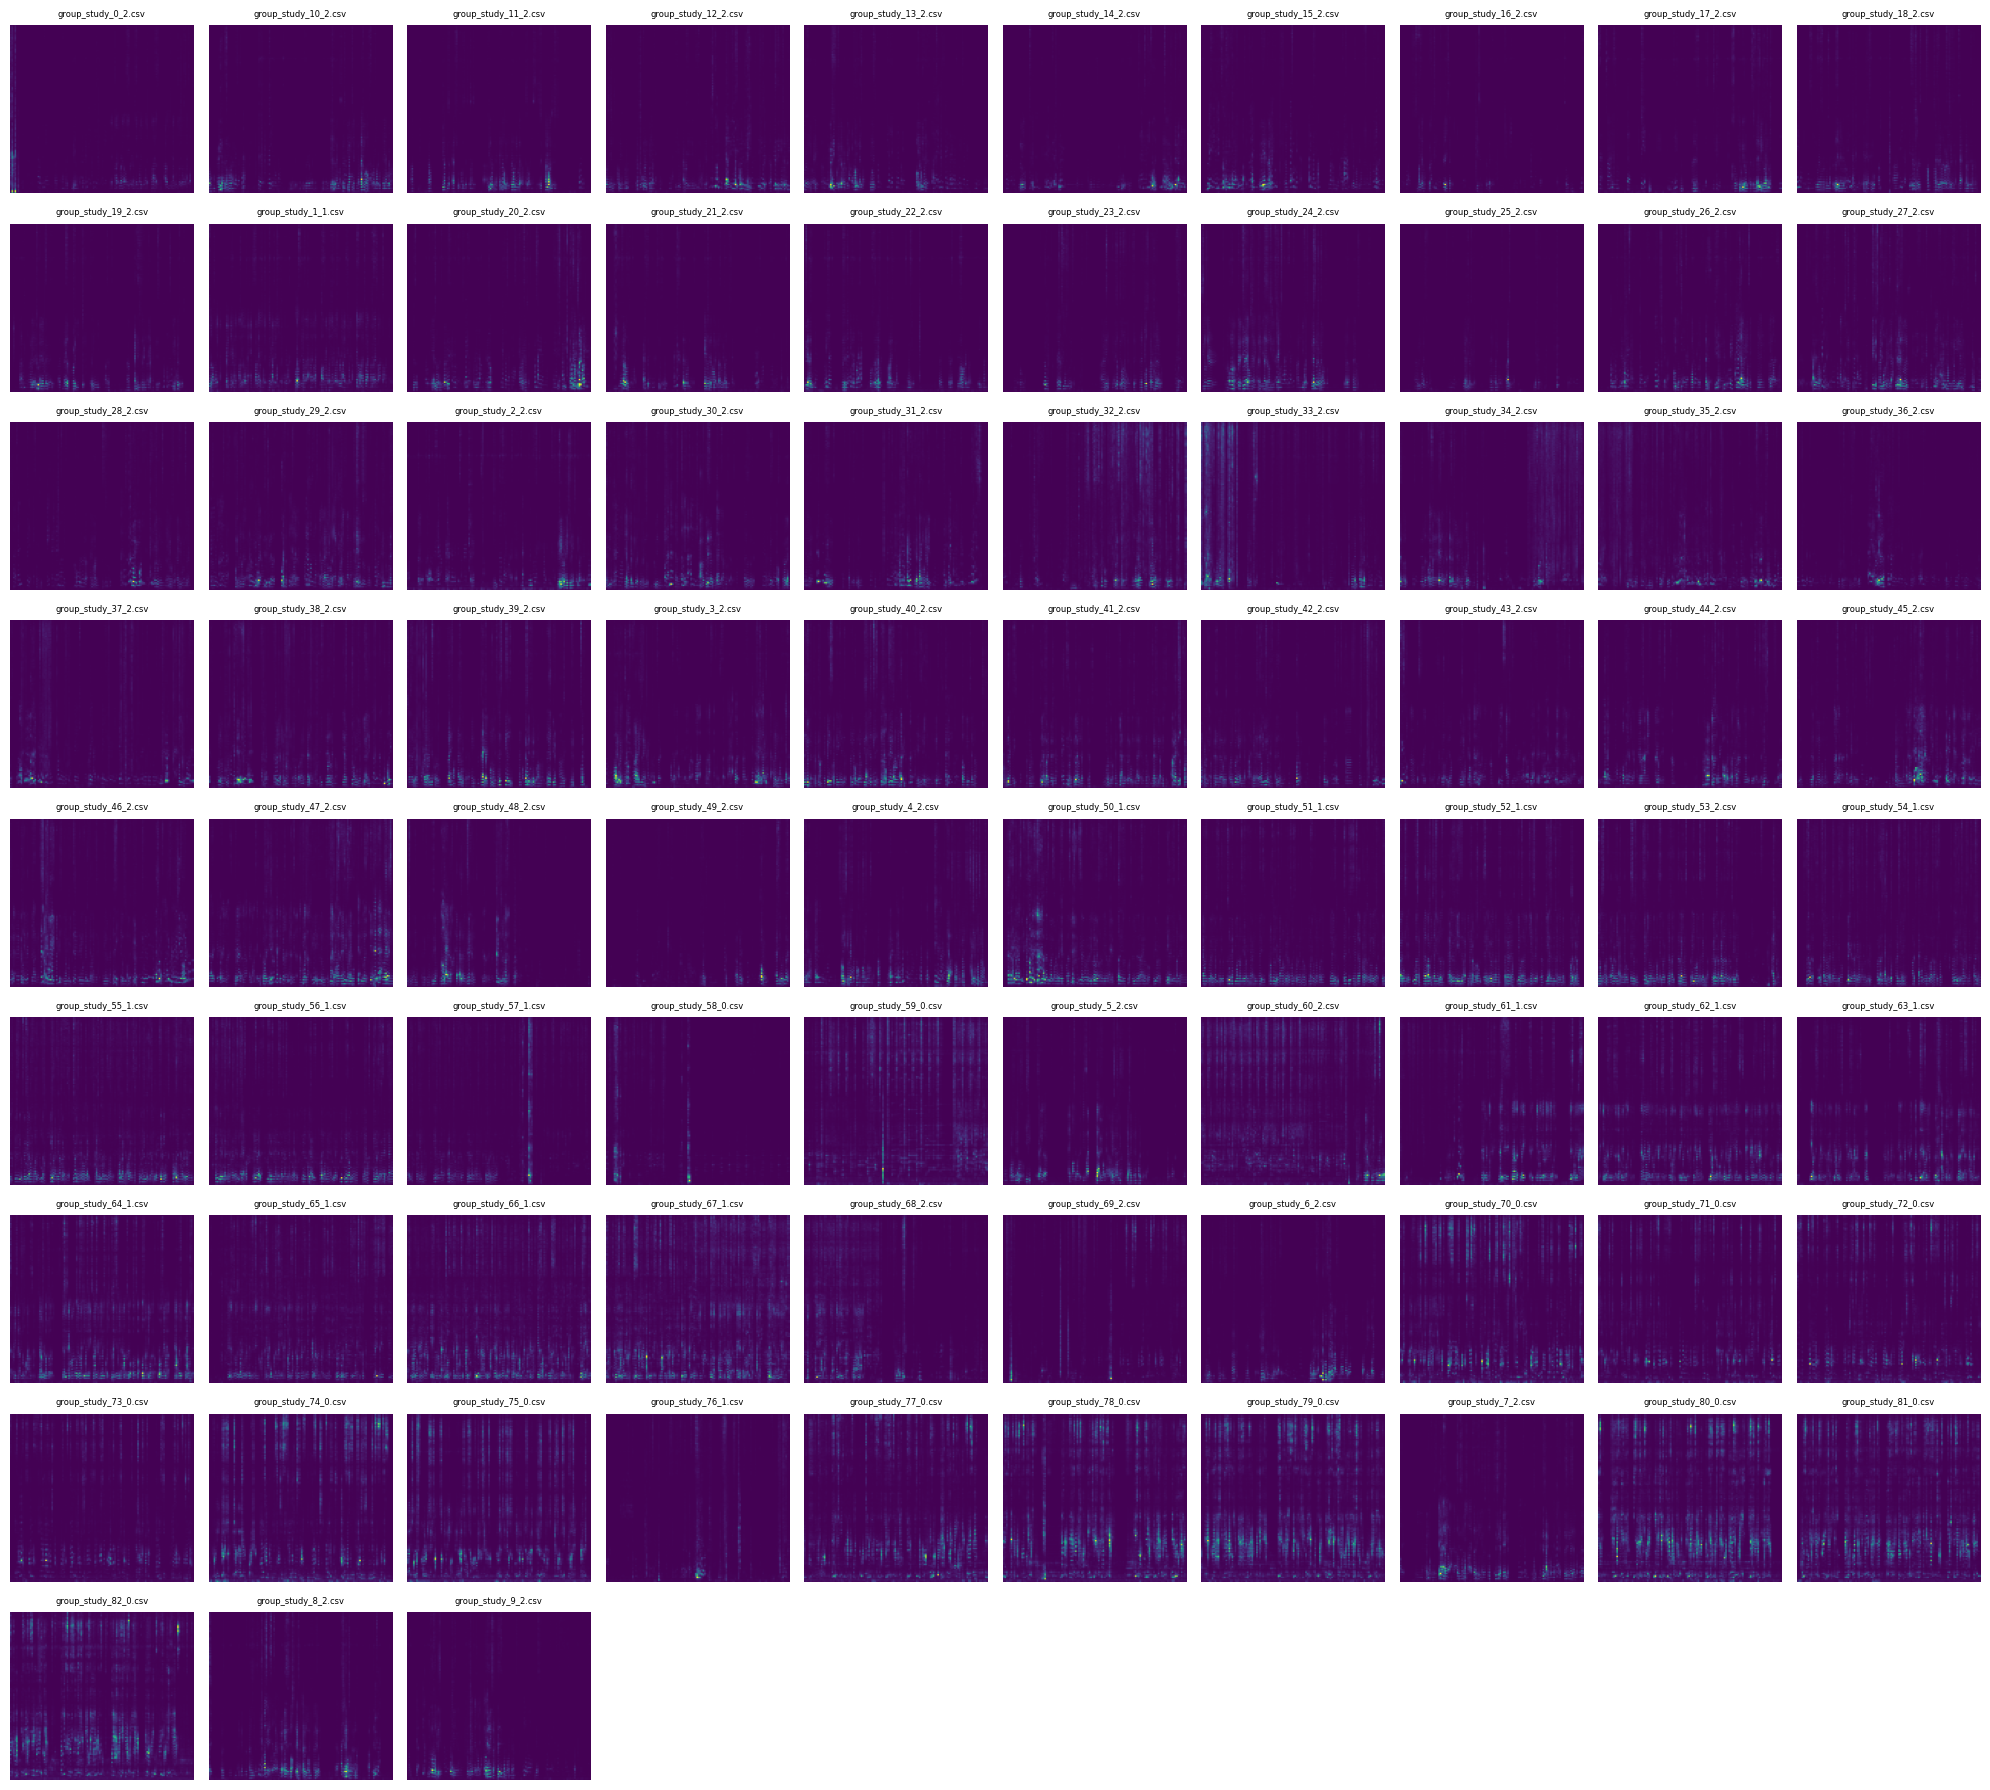

In [20]:
plot_all_spectrograms(
    r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec"
)

In [25]:
import numpy as np

def load_all_csv_in_participant(participant_folder):
    files = sorted(glob.glob(os.path.join(participant_folder, "feat_30sec", "*.csv")))
    return files

def load_mean_spectrogram(participant_folder):
    files = load_all_csv_in_participant(participant_folder)
    all_data = []

    for f in files:
        data = pd.read_csv(f, header=None).values
        if data.shape != (128, 120):
            print(f"Skip {f} because shape is {data.shape}")
            continue
        all_data.append(data)

    if len(all_data) == 0:
        raise ValueError(f"No valid CSV files found in {participant_folder}")

    mean_spec = np.mean(np.stack(all_data, axis=0), axis=0)
    return mean_spec, files

=== p10 example files ===
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec\group_study_0_2.csv
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec\group_study_10_2.csv
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec\group_study_11_2.csv
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec\group_study_12_2.csv
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10\feat_30sec\group_study_13_2.csv

=== p11 example files ===
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p11\feat_30sec\group_study_0_1.csv
C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p11\feat_30sec\group_study_10_1.csv
C:\Users\User\Downloads\audio-controlle

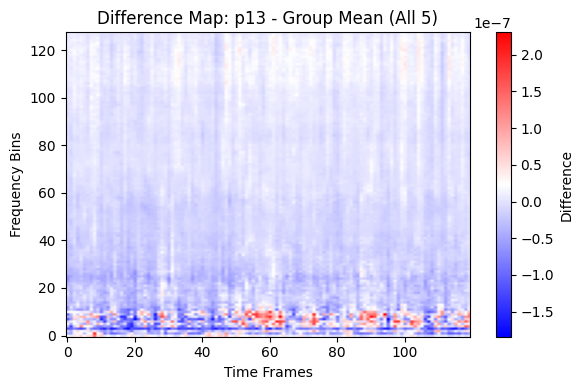

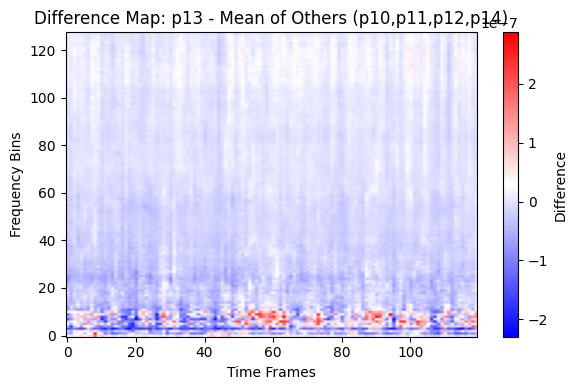

In [26]:
p10_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p10"
p11_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p11"
p12_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p12"
p13_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p13"
p14_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p14"

p10_mean, p10_files = load_mean_spectrogram(p10_path)
p11_mean, p11_files = load_mean_spectrogram(p11_path)
p12_mean, p12_files = load_mean_spectrogram(p12_path)
p13_mean, p13_files = load_mean_spectrogram(p13_path)
p14_mean, p14_files = load_mean_spectrogram(p14_path)

# STEP 1: check files
print("=== p10 example files ===")
for f in p10_files[:5]:
    print(f)

print("\n=== p11 example files ===")
for f in p11_files[:5]:
    print(f)

print("\n=== p12 example files ===")
for f in p12_files[:5]:
    print(f)

print("\n=== p13 example files ===")
for f in p13_files[:5]:
    print(f)

print("\n=== p14 example files ===")
for f in p14_files[:5]:
    print(f)

# STEP 2: check summary stats
print("\n=== Mean values ===")
print("p10 mean:", np.mean(p10_mean))
print("p11 mean:", np.mean(p11_mean))
print("p12 mean:", np.mean(p12_mean))
print("p13 mean:", np.mean(p13_mean))
print("p14 mean:", np.mean(p14_mean))

print("\n=== Std values ===")
print("p10 std:", np.std(p10_mean))
print("p11 std:", np.std(p11_mean))
print("p12 std:", np.std(p12_mean))
print("p13 std:", np.std(p13_mean))
print("p14 std:", np.std(p14_mean))

# STEP 3A: pairwise difference maps
diff_13_10 = p13_mean - p10_mean
diff_13_11 = p13_mean - p11_mean
diff_13_12 = p13_mean - p12_mean
diff_13_14 = p13_mean - p14_mean

# STEP 3B: group mean of all 5 participants
group_mean = (p10_mean + p11_mean + p12_mean + p13_mean + p14_mean) / 5

# STEP 3C: others mean (exclude p13)
others_mean_excluding_p13 = (p10_mean + p11_mean + p12_mean + p14_mean) / 4

# STEP 3D: difference of p13 vs group mean / others mean
diff_13_vs_group = p13_mean - group_mean
diff_13_vs_others = p13_mean - others_mean_excluding_p13

# plot p13 vs all-group mean
plt.figure(figsize=(6, 4))
plt.imshow(diff_13_vs_group, cmap="bwr", aspect="auto", origin="lower")
plt.colorbar(label="Difference")
plt.title("Difference Map: p13 - Group Mean (All 5)")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.tight_layout()
plt.show()

# plot p13 vs others mean
plt.figure(figsize=(6, 4))
plt.imshow(diff_13_vs_others, cmap="bwr", aspect="auto", origin="lower")
plt.colorbar(label="Difference")
plt.title("Difference Map: p13 - Mean of Others (p10,p11,p12,p14)")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.tight_layout()
plt.show()

In [27]:
p11_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p11"
p12_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p12"
p13_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p13"
p14_path = r"C:\Users\User\Downloads\audio-controlled-dataset\audio_imu_conversational_data\audio_features\p14"

p11_mean, p11_files = load_mean_spectrogram(p11_path)
p12_mean, p12_files = load_mean_spectrogram(p12_path)
p13_mean, p13_files = load_mean_spectrogram(p13_path)
p14_mean, p14_files = load_mean_spectrogram(p14_path)

print("p11 mean/std:", np.mean(p11_mean), np.std(p11_mean))
print("p12 mean/std:", np.mean(p12_mean), np.std(p12_mean))
print("p13 mean/std:", np.mean(p13_mean), np.std(p13_mean))
print("p14 mean/std:", np.mean(p14_mean), np.std(p14_mean))

p11 mean/std: 6.872815741042187e-08 7.949722276564222e-08
p12 mean/std: 8.703848194691002e-08 1.1008298968437559e-07
p13 mean/std: 8.182248274943055e-08 1.1016218696108762e-07
p14 mean/std: 1.1060735605841074e-07 1.705870270199635e-07


C:\Users\User\AppData\Local\Temp\ipykernel_16296\3120259640.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


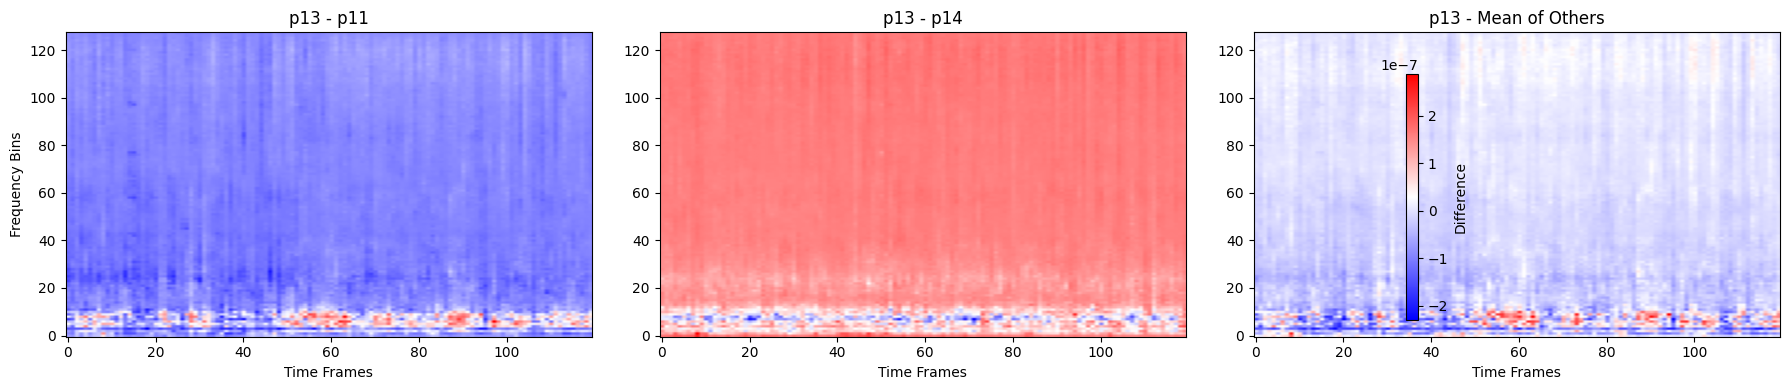

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].imshow(diff_13_11, cmap="bwr", aspect="auto", origin="lower")
axes[0].set_title("p13 - p11")
axes[0].set_xlabel("Time Frames")
axes[0].set_ylabel("Frequency Bins")

axes[1].imshow(diff_13_14, cmap="bwr", aspect="auto", origin="lower")
axes[1].set_title("p13 - p14")
axes[1].set_xlabel("Time Frames")

im = axes[2].imshow(diff_13_vs_others, cmap="bwr", aspect="auto", origin="lower")
axes[2].set_title("p13 - Mean of Others")
axes[2].set_xlabel("Time Frames")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Difference")
plt.tight_layout()
plt.show()

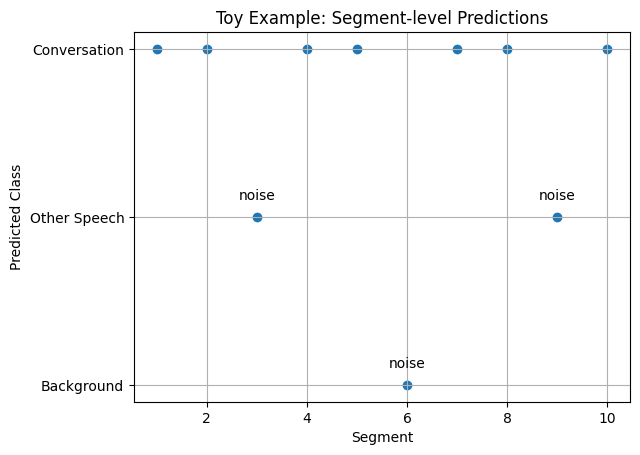

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ตัวอย่างข้อมูล (segment-level prediction)
segments = np.arange(1, 11)
predictions = [2, 2, 1, 2, 2, 0, 2, 2, 1, 2]  # 0=BG, 1=Other, 2=Conversation

# plot
plt.figure()
plt.scatter(segments, predictions)

# ตั้งชื่อ class บนแกน Y
plt.yticks([0,1,2], ['Background', 'Other Speech', 'Conversation'])

plt.xlabel('Segment')
plt.ylabel('Predicted Class')
plt.title('Toy Example: Segment-level Predictions')

# annotation จุดผิด (noise)
for i, val in enumerate(predictions):
    if val != 2:
        plt.text(segments[i], val+0.1, 'noise', ha='center')

plt.grid()

plt.show()

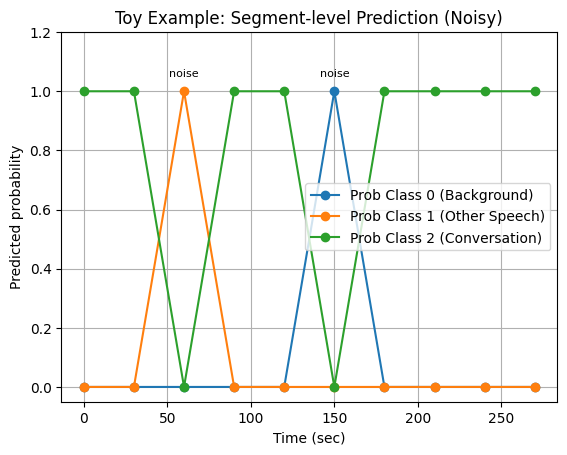

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# สร้างข้อมูลตัวอย่าง (toy)
# ------------------------
time_steps = np.arange(0, 300, 30)  # 30-sec segments

# สมมติว่า "จริง ๆ" เป็น conversation (class 2)
# แต่มี noise บางช่วง
prob_class_2 = np.array([1,1,0,1,1,0,1,1,1,1])  # conversation
prob_class_1 = np.array([0,0,1,0,0,0,0,0,0,0])  # other speech
prob_class_0 = np.array([0,0,0,0,0,1,0,0,0,0])  # background

# ------------------------
# Plot
# ------------------------
plt.figure()

plt.plot(time_steps, prob_class_0, marker='o', label='Prob Class 0 (Background)')
plt.plot(time_steps, prob_class_1, marker='o', label='Prob Class 1 (Other Speech)')
plt.plot(time_steps, prob_class_2, marker='o', label='Prob Class 2 (Conversation)')

# ------------------------
# Highlight จุด noise
# ------------------------
for i, t in enumerate(time_steps):
    if prob_class_2[i] == 0:
        plt.text(t, 1.05, 'noise', ha='center', fontsize=8)

# ------------------------
# Styling (เหมือนของคุณ)
# ------------------------
plt.xlabel('Time (sec)')
plt.ylabel('Predicted probability')
plt.title('Toy Example: Segment-level Prediction (Noisy)')

plt.ylim(-0.05, 1.2)
plt.grid()
plt.legend()

plt.show()

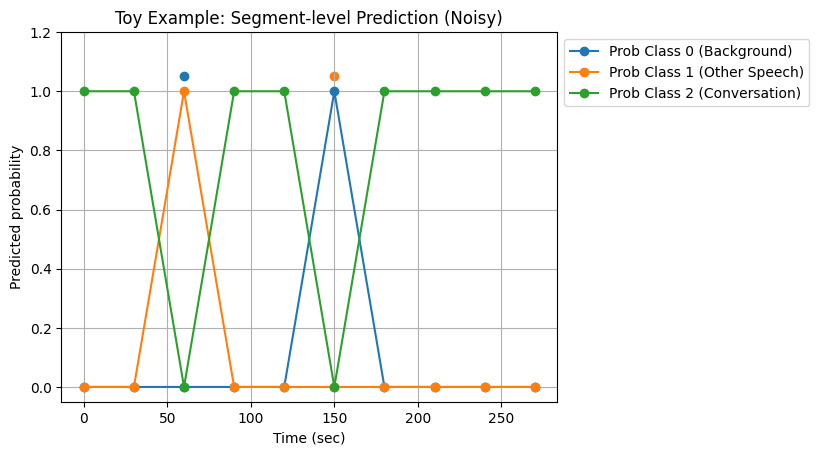

In [7]:
plt.figure()

plt.plot(time_steps, prob_class_0, marker='o', label='Prob Class 0 (Background)')
plt.plot(time_steps, prob_class_1, marker='o', label='Prob Class 1 (Other Speech)')
plt.plot(time_steps, prob_class_2, marker='o', label='Prob Class 2 (Conversation)')

# highlight noise ด้วย marker
for i, t in enumerate(time_steps):
    if prob_class_2[i] == 0:
        plt.scatter(t, 1.05, marker='o')

plt.xlabel('Time (sec)')
plt.ylabel('Predicted probability')
plt.title('Toy Example: Segment-level Prediction (Noisy)')

plt.ylim(-0.05, 1.2)
plt.grid()

# ย้าย legend ออกข้าง
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

Text(150, 1.12, 'Final: Conversation (after aggregation)')



In [4]:
# final decision (majority)
final_class = 2

plt.axhline(y=1.1, linestyle='--')
plt.text(150, 1.12, 'Final: Conversation (after aggregation)', ha='center')

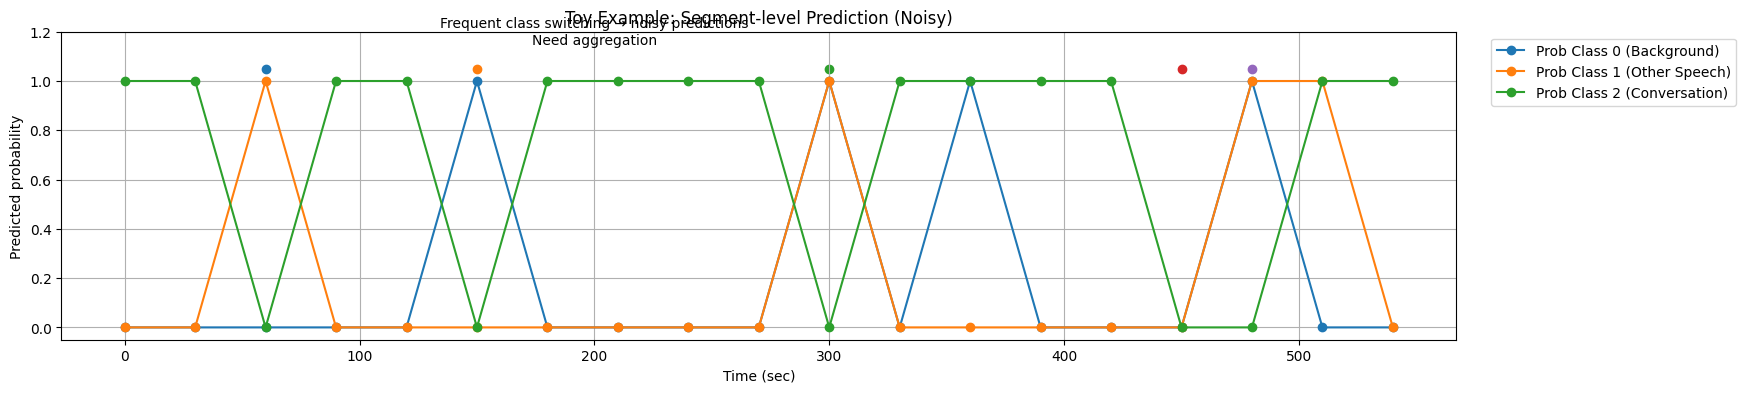

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

prob_class_2 = np.array([1,1,0,1,1,0,1,1,1,1,0,1,1,1,1,0,0,1,1])
prob_class_1 = np.array([0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0])
prob_class_0 = np.array([0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0])

# ✅ แก้ตรงนี้
time_steps = np.arange(len(prob_class_2)) * 30

plt.figure(figsize=(18, 4))

plt.plot(time_steps, prob_class_0, marker='o', label='Prob Class 0 (Background)')
plt.plot(time_steps, prob_class_1, marker='o', label='Prob Class 1 (Other Speech)')
plt.plot(time_steps, prob_class_2, marker='o', label='Prob Class 2 (Conversation)')

# highlight noise
for i, t in enumerate(time_steps):
    if prob_class_2[i] == 0:
        plt.scatter(t, 1.05, marker='o')

plt.xlabel('Time (sec)')
plt.ylabel('Predicted probability')
plt.title('Toy Example: Segment-level Prediction (Noisy)')

plt.ylim(-0.05, 1.2)
plt.grid()

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))


plt.show()

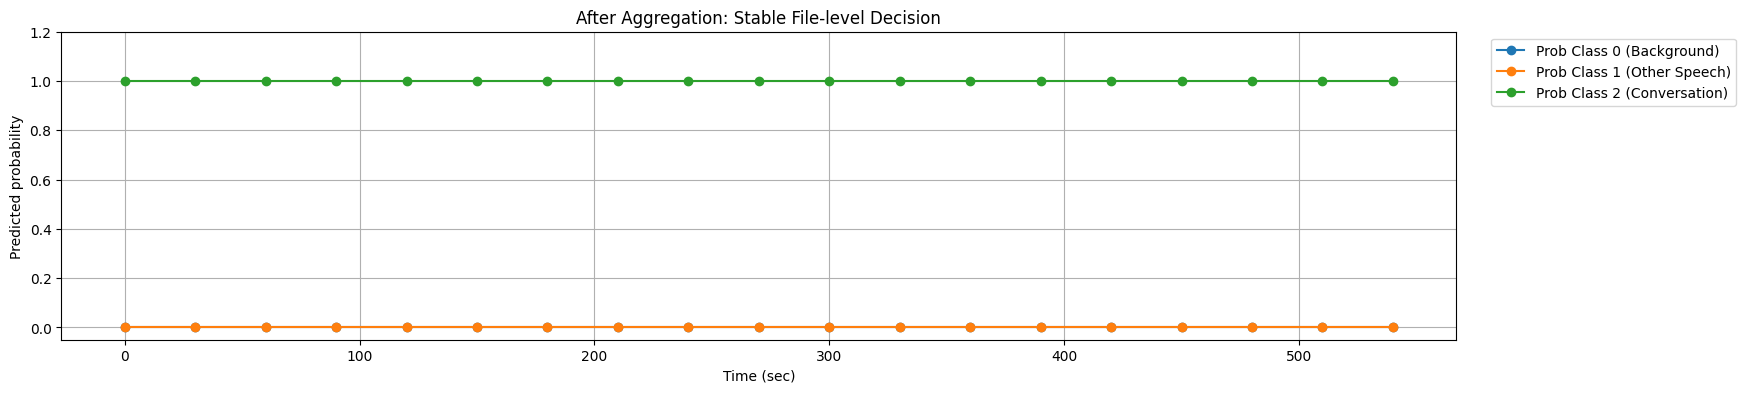

In [15]:
import numpy as np
import matplotlib.pyplot as plt

time_steps = np.arange(0, 570, 30)

# หลัง aggregation ตัดสินเป็น class 2 ทั้งไฟล์
final_class_2 = np.ones_like(time_steps)
final_class_1 = np.zeros_like(time_steps)
final_class_0 = np.zeros_like(time_steps)

plt.figure(figsize=(18, 4))

plt.plot(time_steps, final_class_0, marker='o', label='Prob Class 0 (Background)')
plt.plot(time_steps, final_class_1, marker='o', label='Prob Class 1 (Other Speech)')
plt.plot(time_steps, final_class_2, marker='o', label='Prob Class 2 (Conversation)')

plt.xlabel('Time (sec)')
plt.ylabel('Predicted probability')
plt.title('After Aggregation: Stable File-level Decision')

plt.ylim(-0.05, 1.2)
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

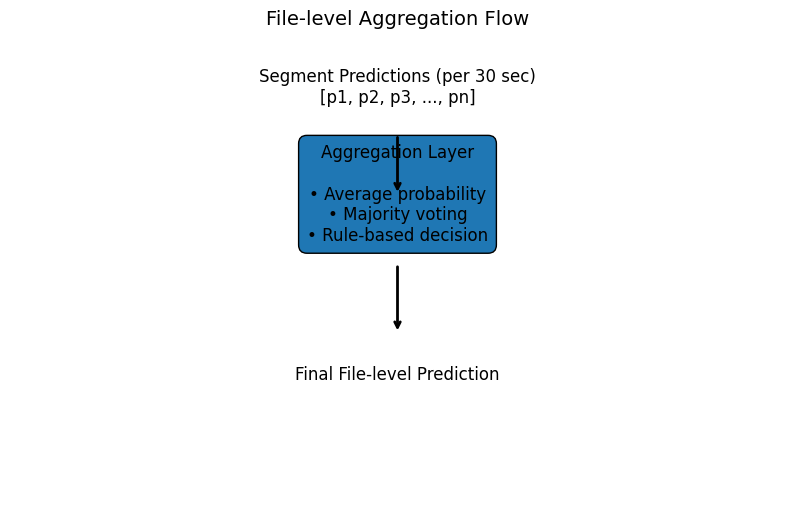

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Text blocks
ax.text(0.5, 0.85, "Segment Predictions (per 30 sec)\n[p1, p2, p3, ..., pn]",
        ha='center', fontsize=12)

ax.text(0.5, 0.55,
        "Aggregation Layer\n\n• Average probability\n• Majority voting\n• Rule-based decision",
        ha='center', fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5"))

ax.text(0.5, 0.25, "Final File-level Prediction",
        ha='center', fontsize=12)

# Arrows
ax.annotate('', xy=(0.5, 0.65), xytext=(0.5, 0.78),
            arrowprops=dict(arrowstyle='->', lw=2))

ax.annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.50),
            arrowprops=dict(arrowstyle='->', lw=2))

plt.title("File-level Aggregation Flow", fontsize=14)

plt.show()

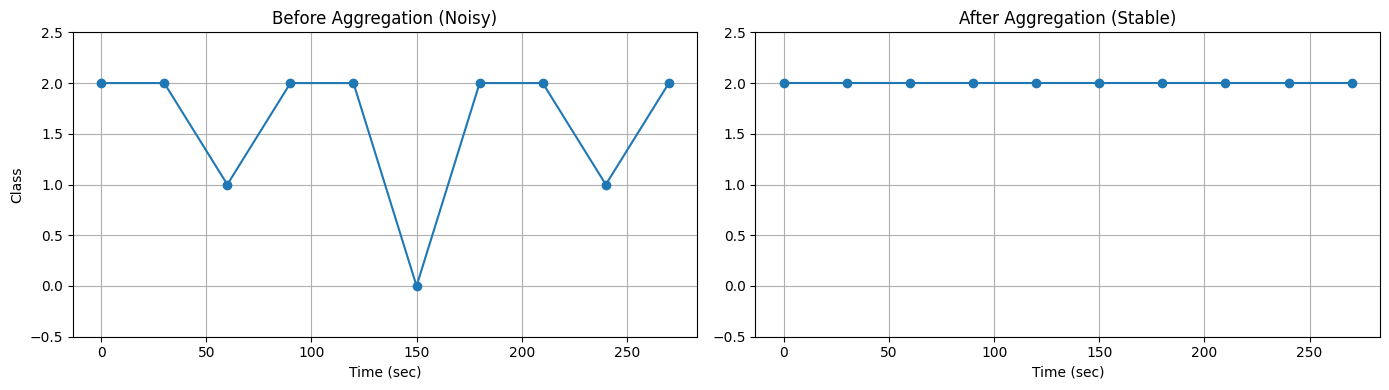

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(0, 300, 30)

# noisy prediction (example)
pred = [2,2,1,2,2,0,2,2,1,2]

# after aggregation (stable)
final = [2]*len(time)

plt.figure(figsize=(14,4))

# before
plt.subplot(1,2,1)
plt.plot(time, pred, marker='o')
plt.title("Before Aggregation (Noisy)")
plt.xlabel("Time (sec)")
plt.ylabel("Class")
plt.ylim(-0.5,2.5)
plt.grid()

# after
plt.subplot(1,2,2)
plt.plot(time, final, marker='o')
plt.title("After Aggregation (Stable)")
plt.xlabel("Time (sec)")
plt.ylim(-0.5,2.5)
plt.grid()

plt.tight_layout()
plt.show()